# Интерпретация

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.feature_selection import VarianceThreshold
import time
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [3]:
data_path = r"C:\Users\annap\VSCode\python\nikolskaya\spbu_ml_2026\additional_materials\datasets\hw_interpretation\data.csv"
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [14]:
df = pd.read_csv(data_path)

df = df.loc[:, ~df.columns.duplicated()]

y = df["price_target"]
X = df.drop(columns=["price_target"])

X = X.select_dtypes(include=[np.number])

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

selector = VarianceThreshold(threshold=0.01)
X = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mse, rmse, mape

results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
results.append(["LR", "no_scale", *metrics(y_test, pred)])

lr_s = LinearRegression()
lr_s.fit(X_train_scaled, y_train)
pred = lr_s.predict(X_test_scaled)
results.append(["LR", "scale", *metrics(y_test, pred)])

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
pred = lasso.predict(X_test)
results.append(["Lasso", "no_scale", *metrics(y_test, pred)])

lasso_s = Lasso(alpha=0.1)
lasso_s.fit(X_train_scaled, y_train)
pred = lasso_s.predict(X_test_scaled)
results.append(["Lasso", "scale", *metrics(y_test, pred)])

gbr = GradientBoostingRegressor(max_depth=5, random_state=42)
gbr.fit(X_train, y_train)
pred = gbr.predict(X_test)
results.append(["GBR", "no_scale", *metrics(y_test, pred)])

gbr_s = GradientBoostingRegressor(max_depth=5, random_state=42)
gbr_s.fit(X_train_scaled, y_train)
pred = gbr_s.predict(X_test_scaled)
results.append(["GBR", "scale", *metrics(y_test, pred)])

res_df = pd.DataFrame(results, columns=["model", "data", "MSE", "RMSE", "MAPE"])
print(res_df)

   model      data           MSE         RMSE      MAPE
0     LR  no_scale  2.310992e+07  4807.278322  0.111189
1     LR     scale  2.310992e+07  4807.278322  0.111189
2  Lasso  no_scale  2.447832e+07  4947.557012  0.115108
3  Lasso     scale  2.447834e+07  4947.559496  0.115094
4    GBR  no_scale  3.778605e+06  1943.863504  0.042552
5    GBR     scale  3.797925e+06  1948.826628  0.042455


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

lasso_std = Lasso(alpha=0.1)
lasso_std.fit(X_train_std, y_train)

lasso_mm = Lasso(alpha=0.1)
lasso_mm.fit(X_train_mm, y_train)

coef_std = pd.Series(lasso_std.coef_, index=X.columns)
coef_mm = pd.Series(lasso_mm.coef_, index=X.columns)

imp_std = coef_std.abs().sort_values(ascending=False)
imp_mm = coef_mm.abs().sort_values(ascending=False)

res_imp = pd.DataFrame({
    "std": imp_std,
    "minmax": imp_mm
})

print(res_imp.head(10))

                                                   std        minmax
class_cat                                  3586.875998  10492.628739
corpus_cat                                  209.927307    728.719456
developer_cat                               418.211613   1863.487033
district_cat                                754.314388   3127.564603
floor                                       179.843252   6341.851432
hc_name_cat                                 209.163367    890.403792
interior_cat                                297.891329    679.306198
location_amenity_bank_w_mean_distance       318.905951   1735.639504
location_amenity_leisure_w_mean_distance   1427.871480   2986.134270
location_amenity_pharmacy_w_mean_distance  3209.093432  22854.179107


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

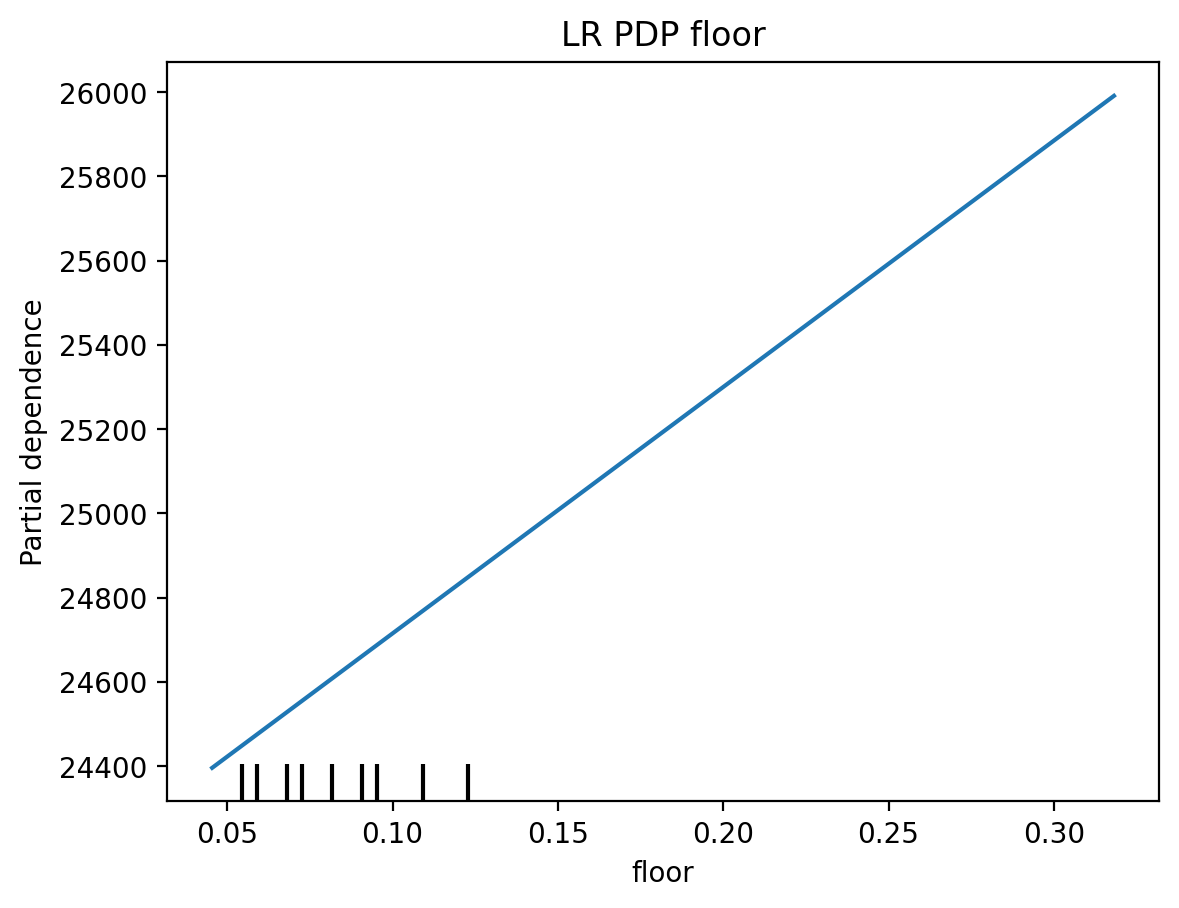

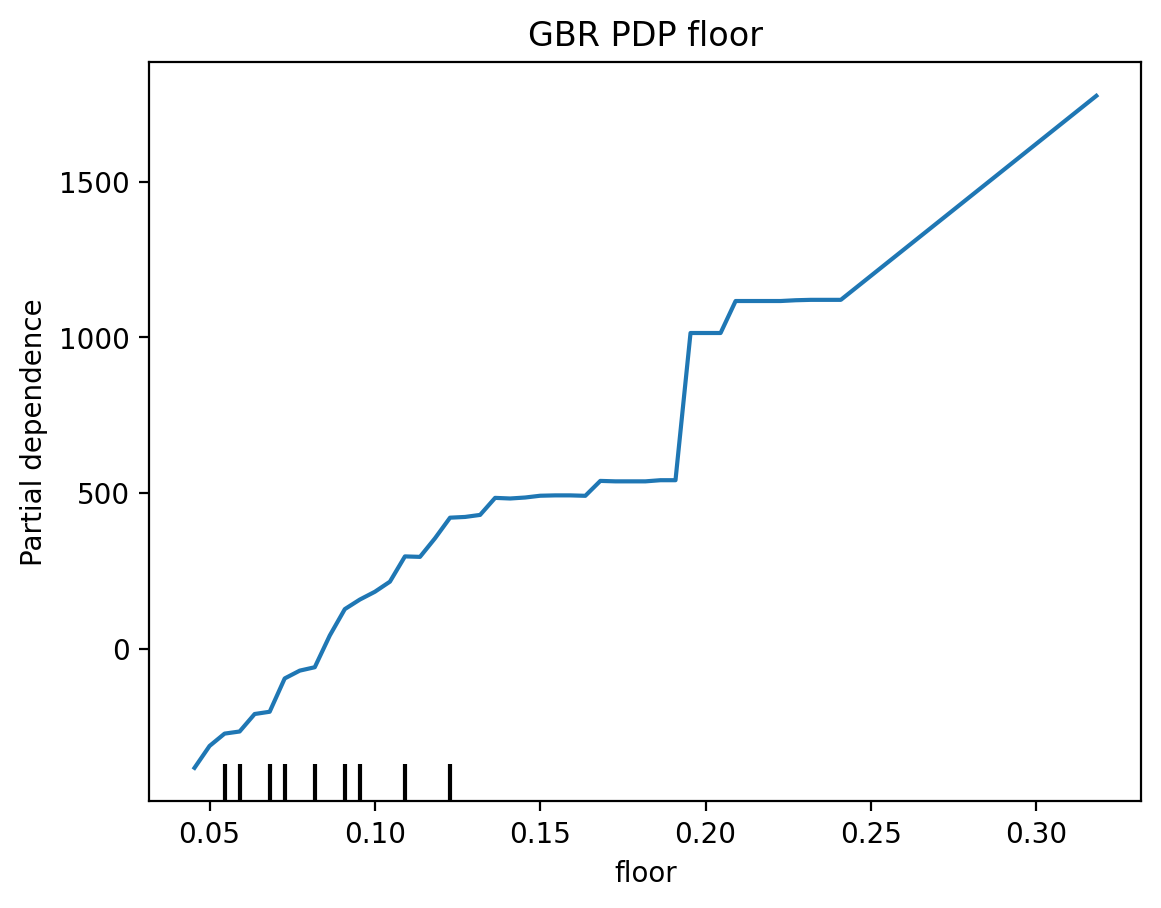

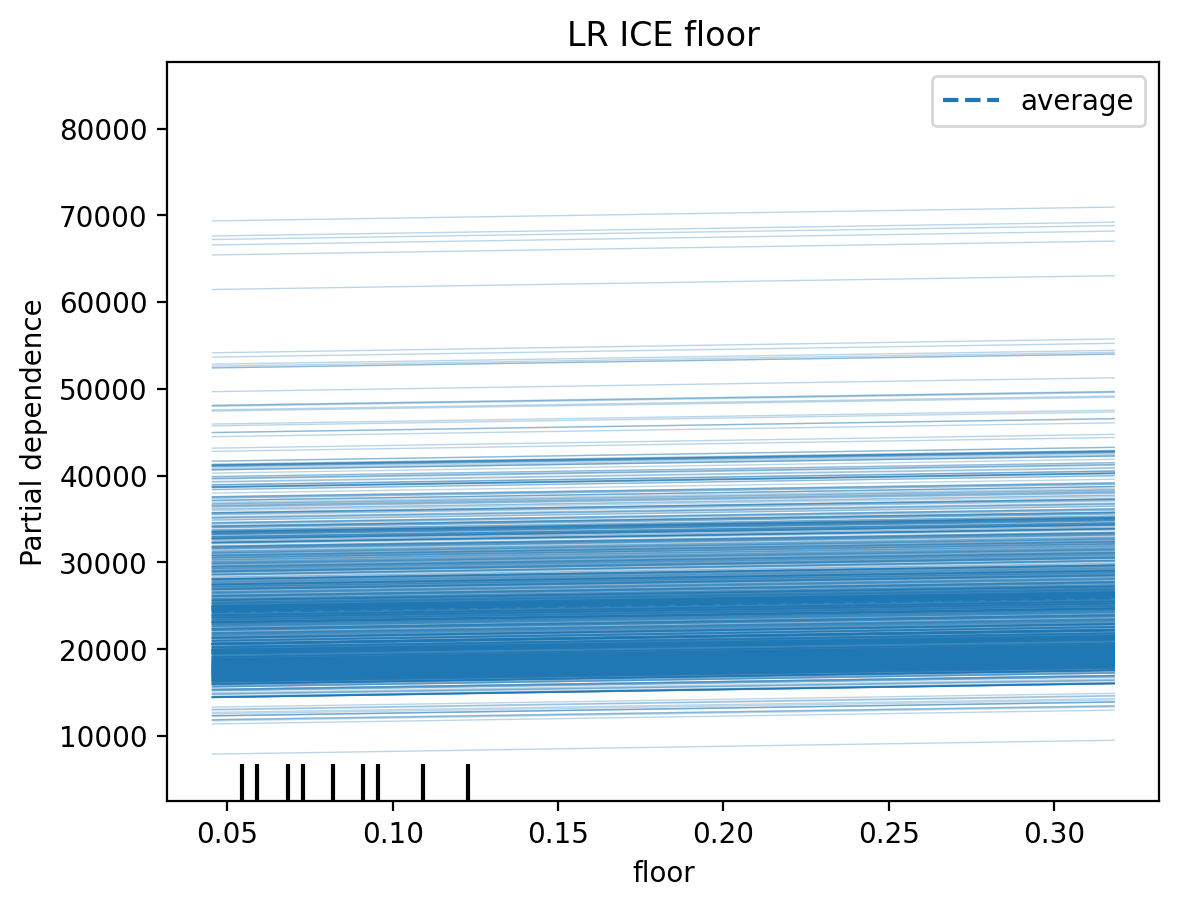

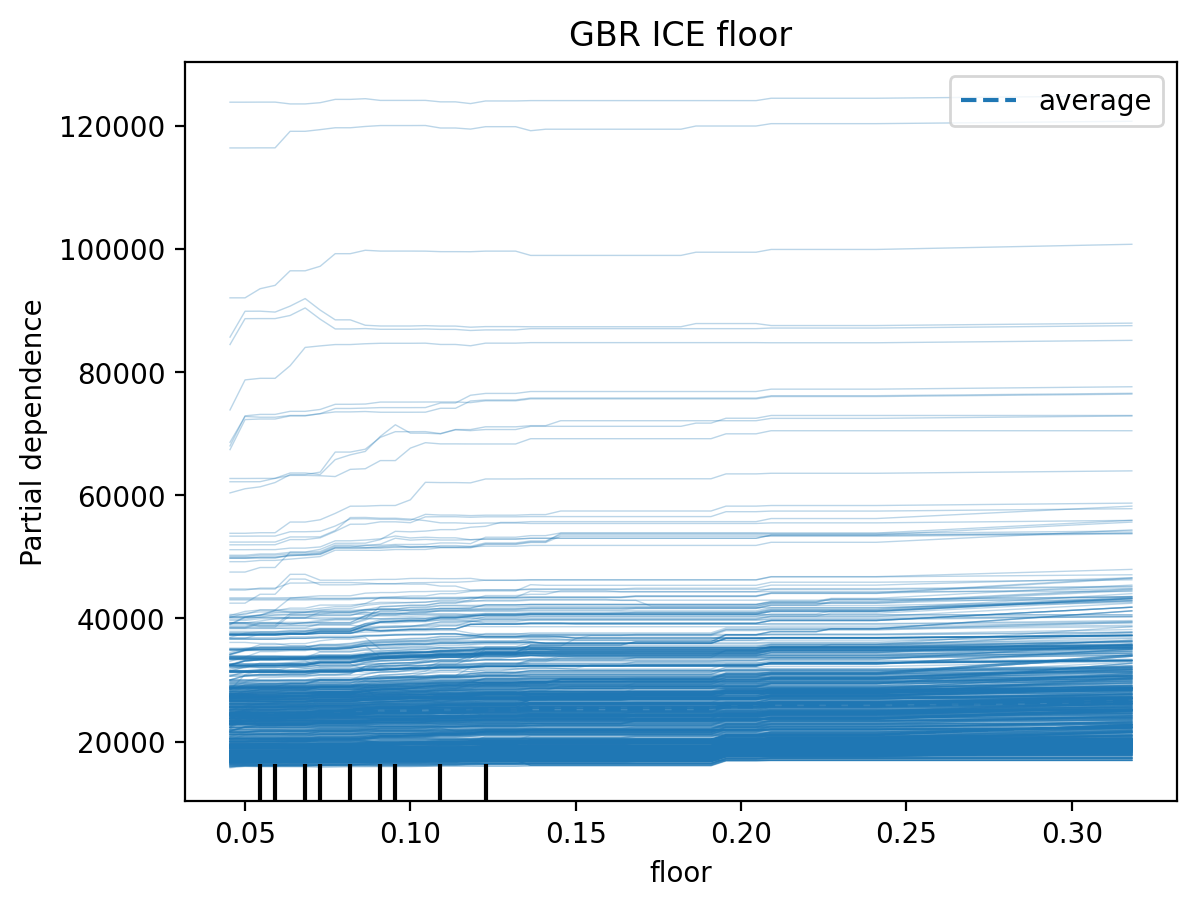

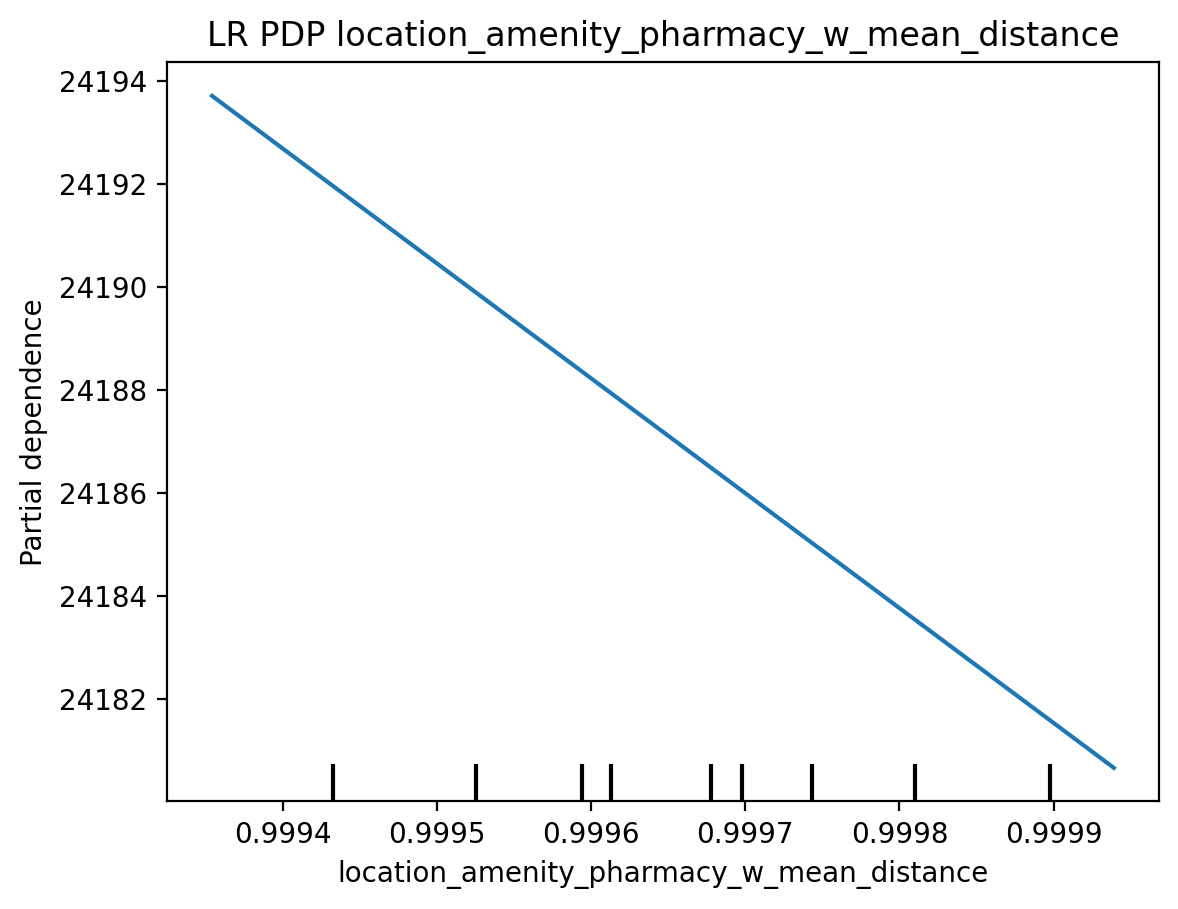

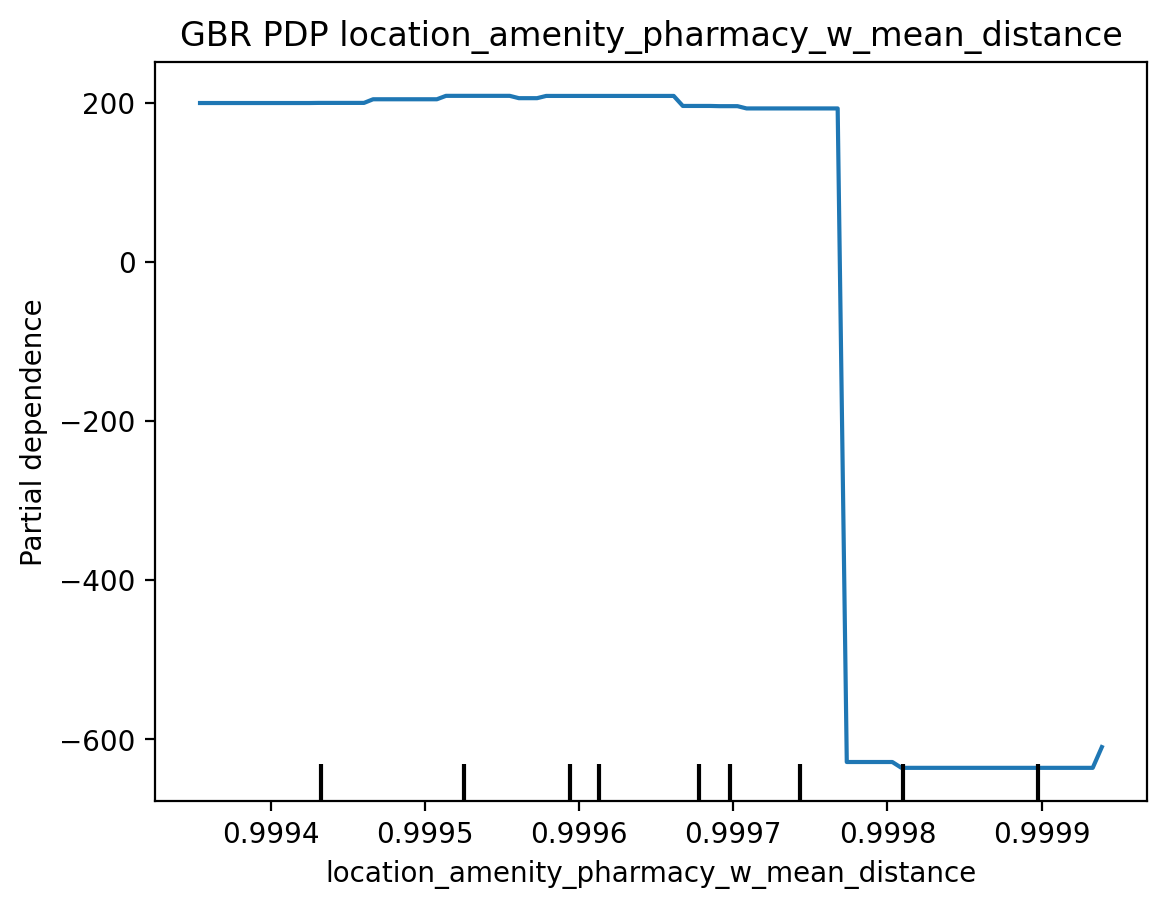

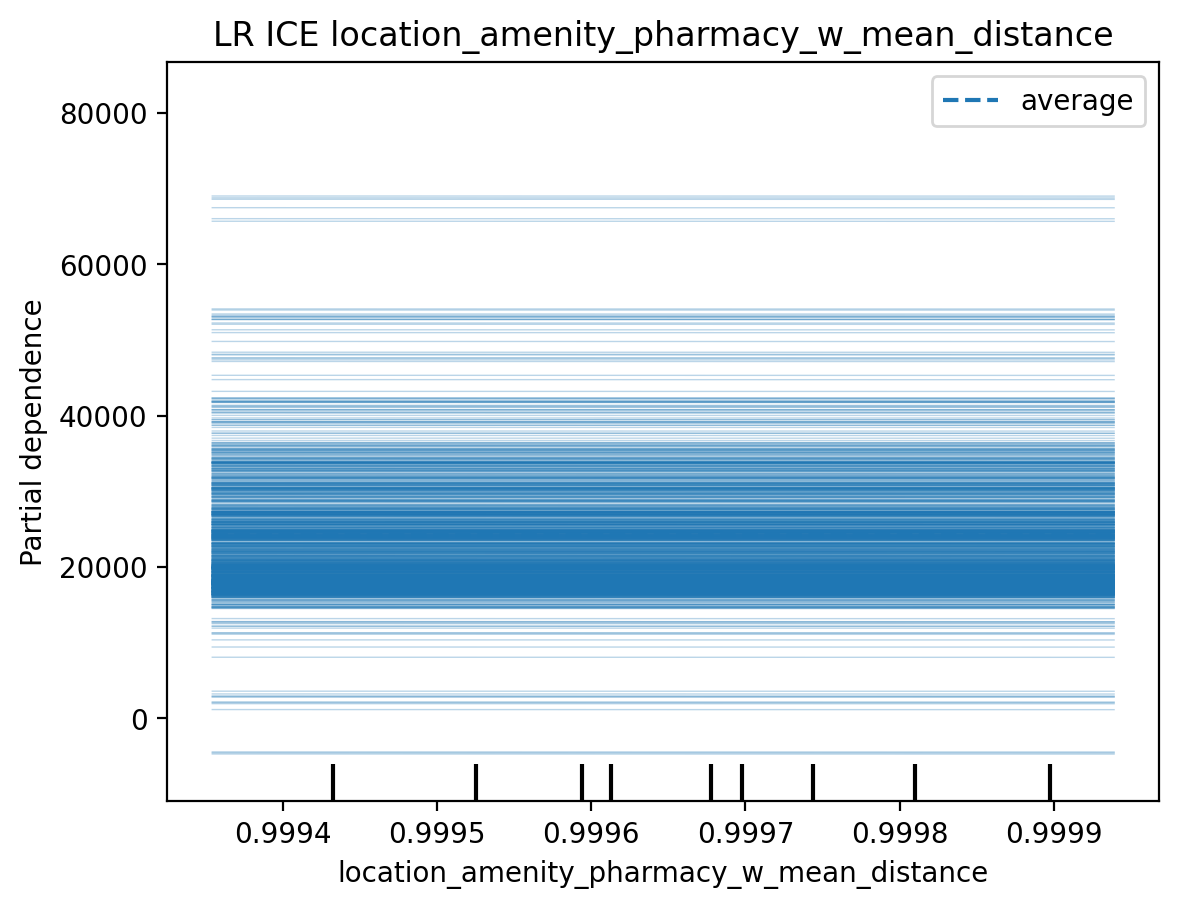

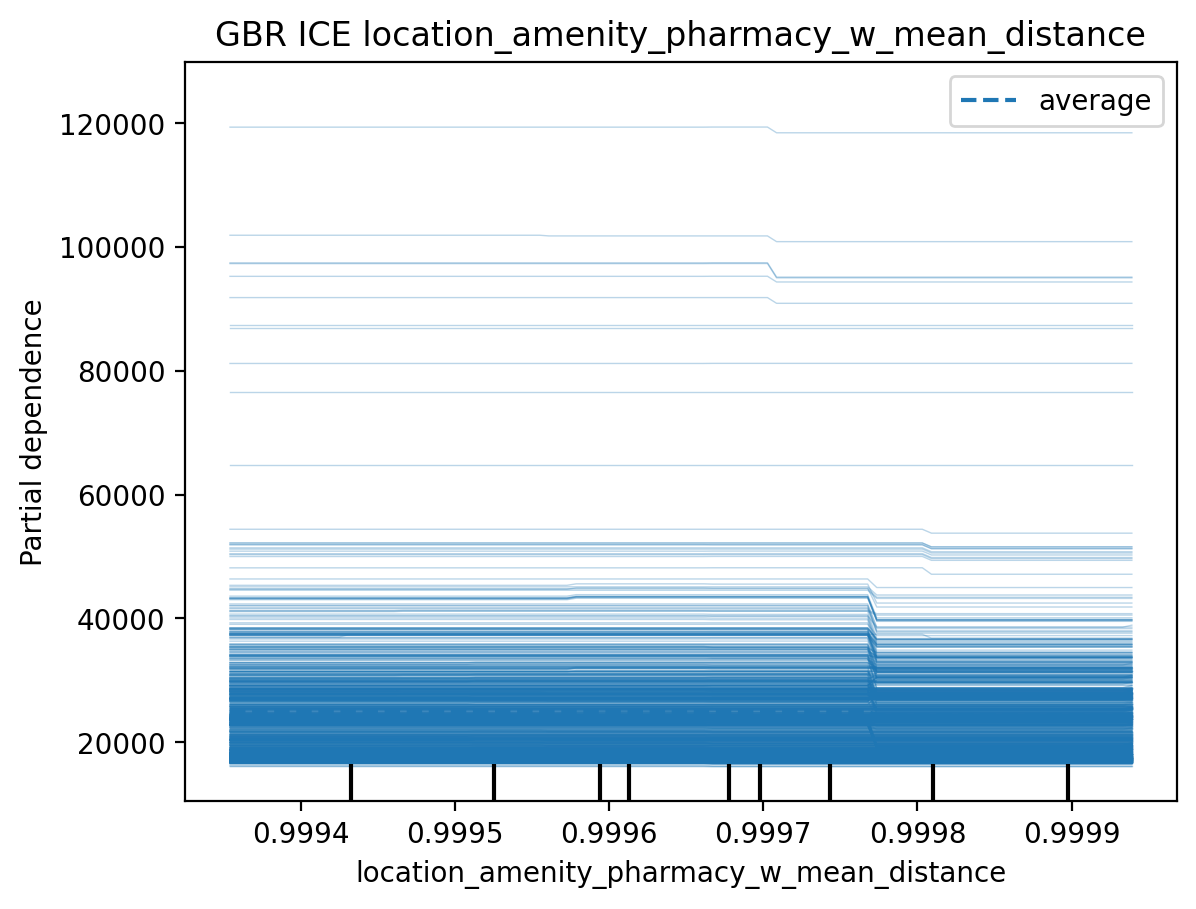

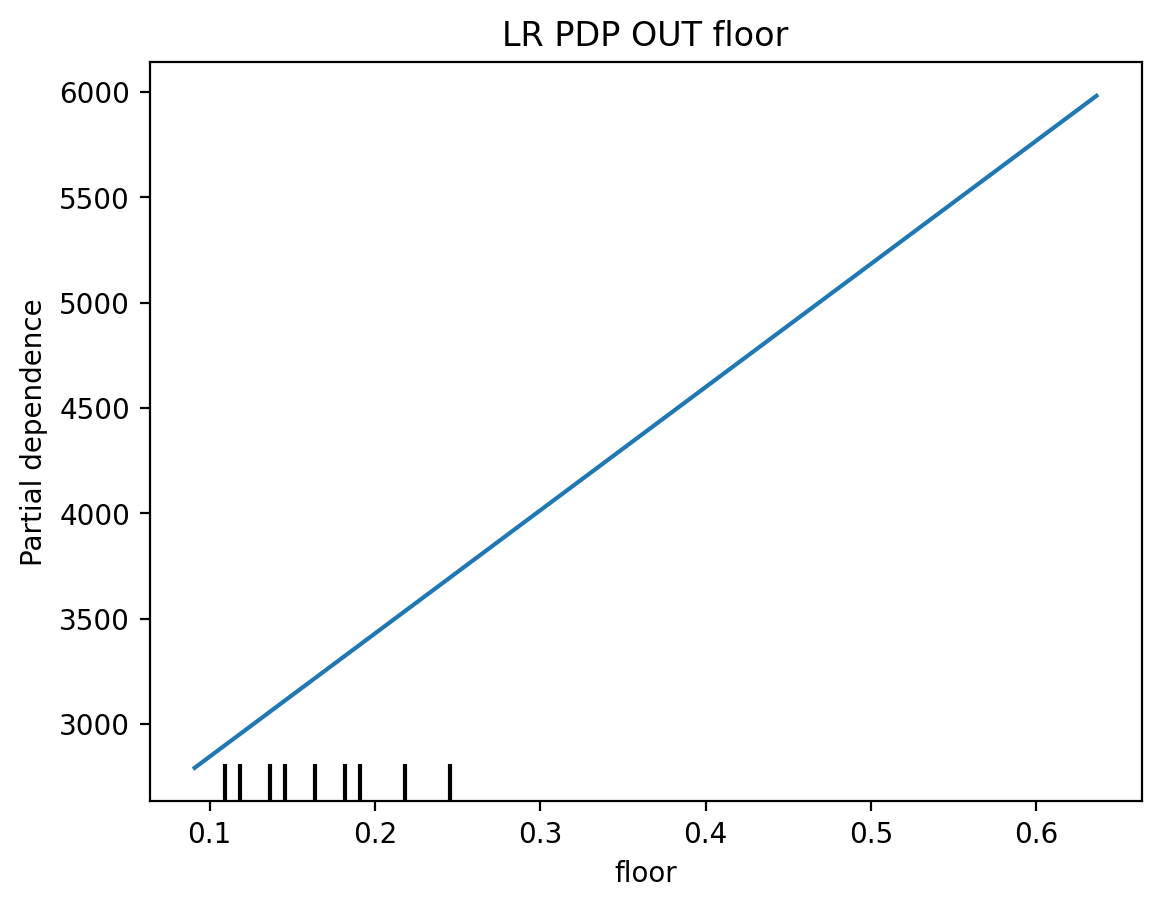

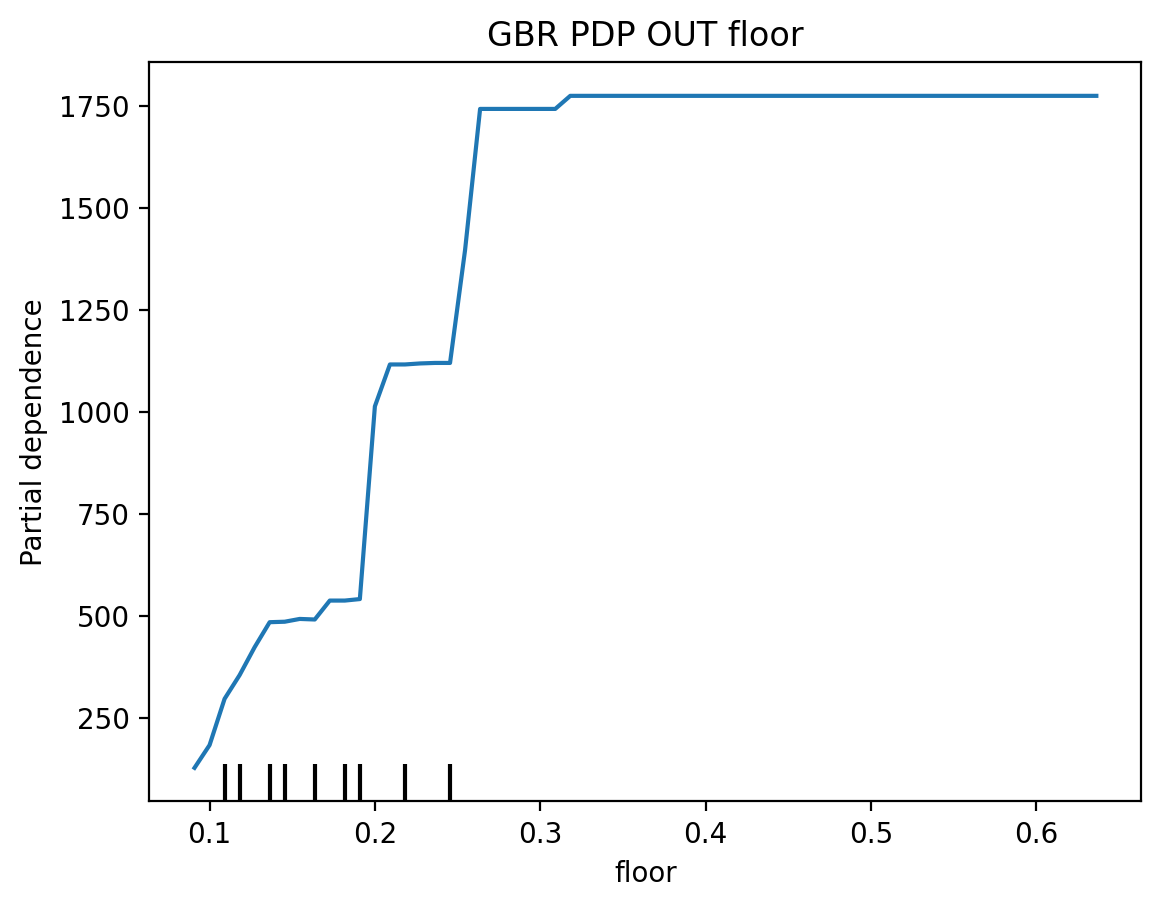

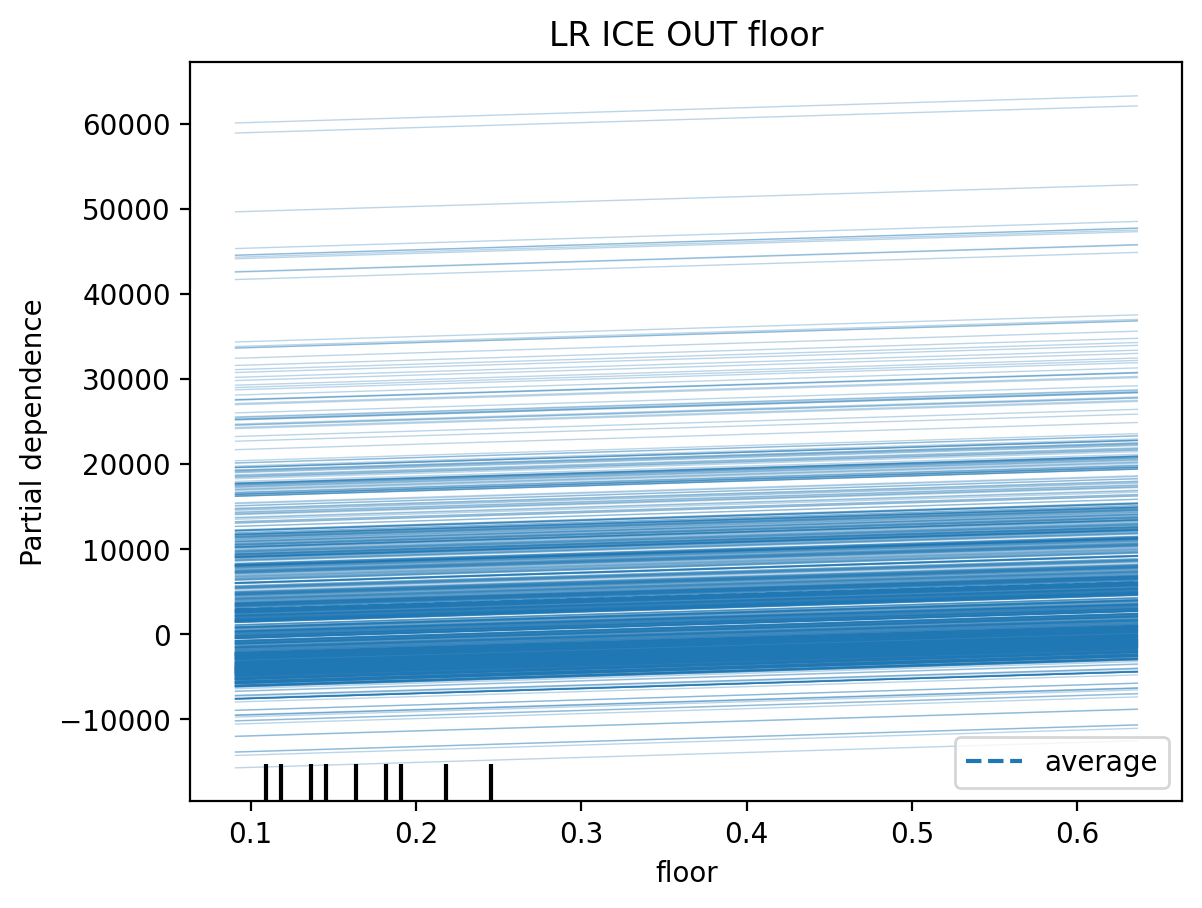

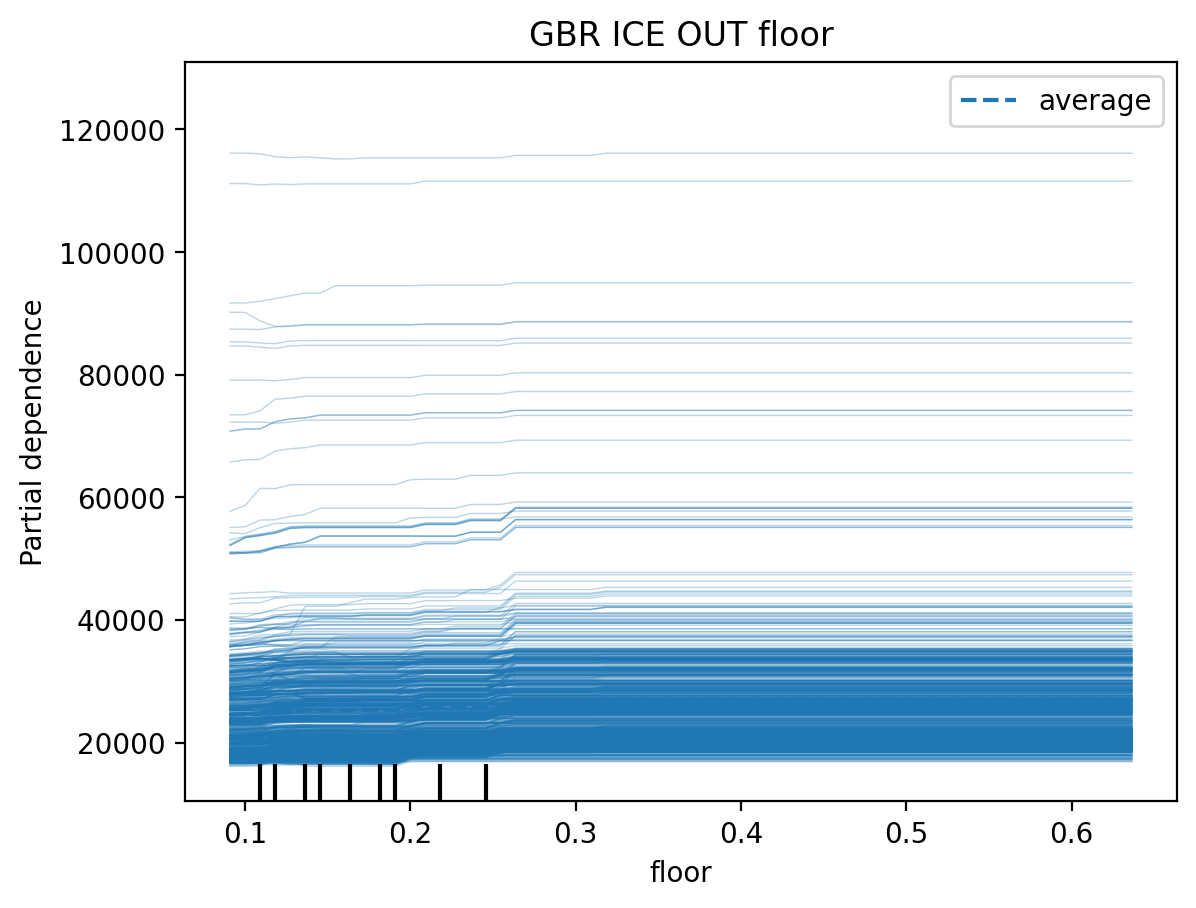

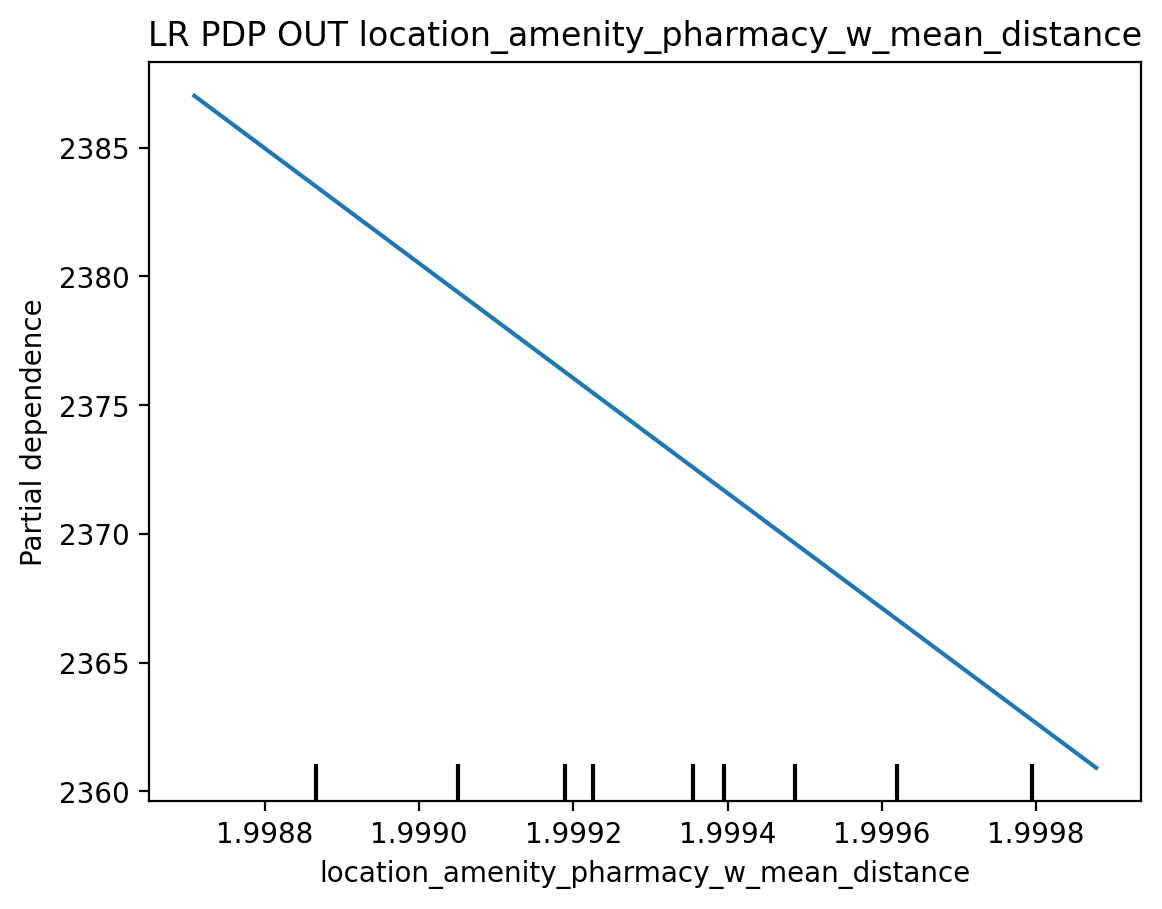

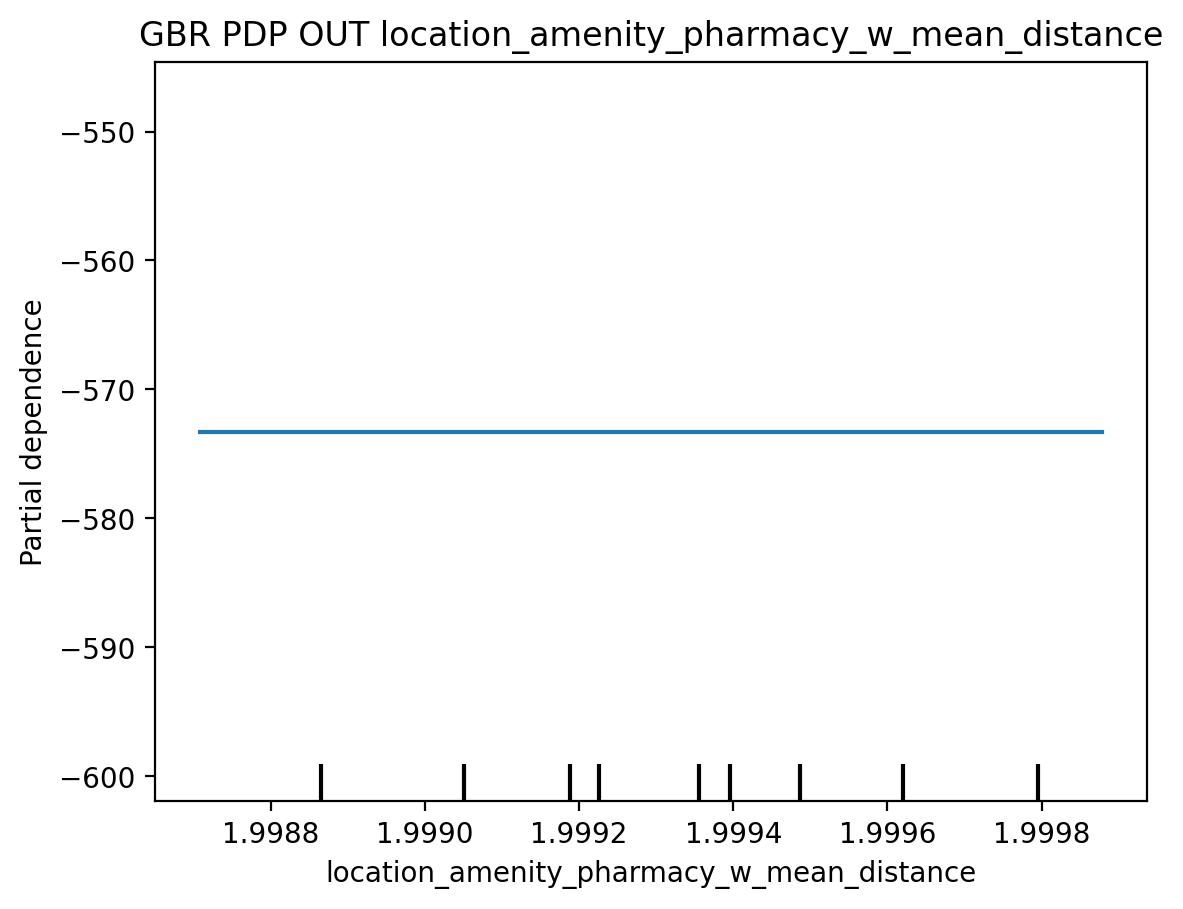

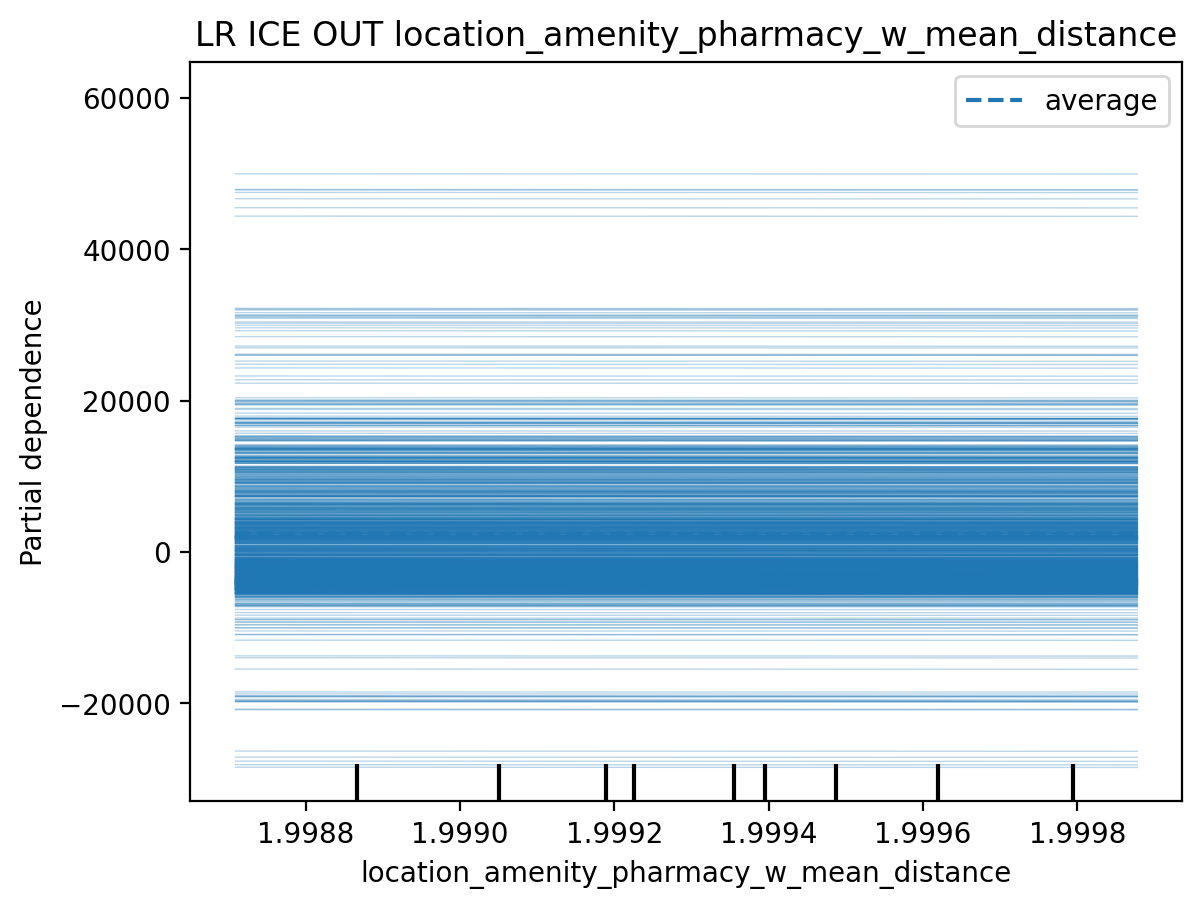

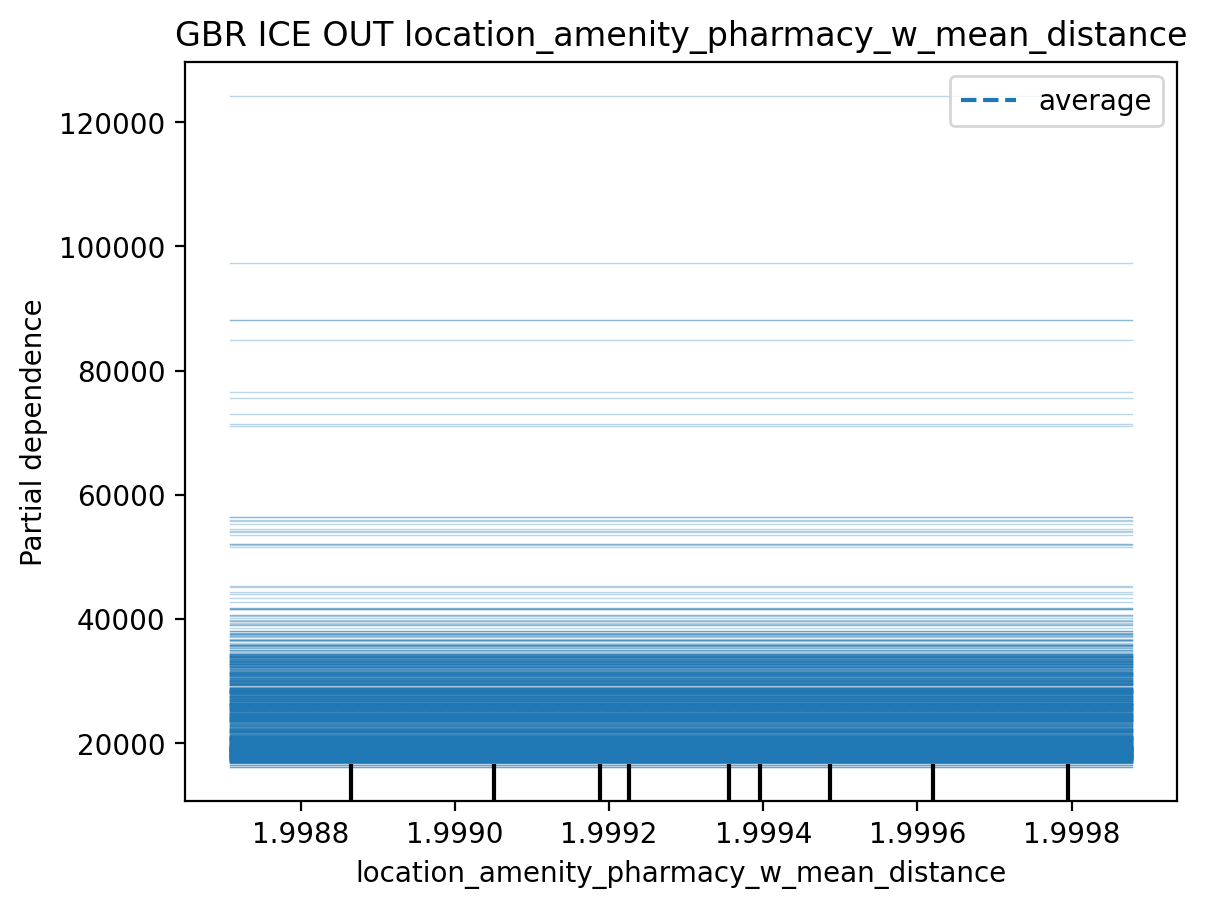

In [16]:
features = ["floor", "location_amenity_pharmacy_w_mean_distance"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

gbr = GradientBoostingRegressor(max_depth=5, random_state=42)
gbr.fit(X_train, y_train)

for f in features:
    PartialDependenceDisplay.from_estimator(lr, X_test, [f])
    plt.title(f"LR PDP {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(gbr, X_test, [f])
    plt.title(f"GBR PDP {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(lr, X_test, [f], kind="both")
    plt.title(f"LR ICE {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(gbr, X_test, [f], kind="both")
    plt.title(f"GBR ICE {f}")
    plt.show()

X_out = X_test.copy()

for f in features:
    X_out[f] = X_out[f] * 2

for f in features:
    PartialDependenceDisplay.from_estimator(lr, X_out, [f])
    plt.title(f"LR PDP OUT {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(gbr, X_out, [f])
    plt.title(f"GBR PDP OUT {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(lr, X_out, [f], kind="both")
    plt.title(f"LR ICE OUT {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(gbr, X_out, [f], kind="both")
    plt.title(f"GBR ICE OUT {f}")
    plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

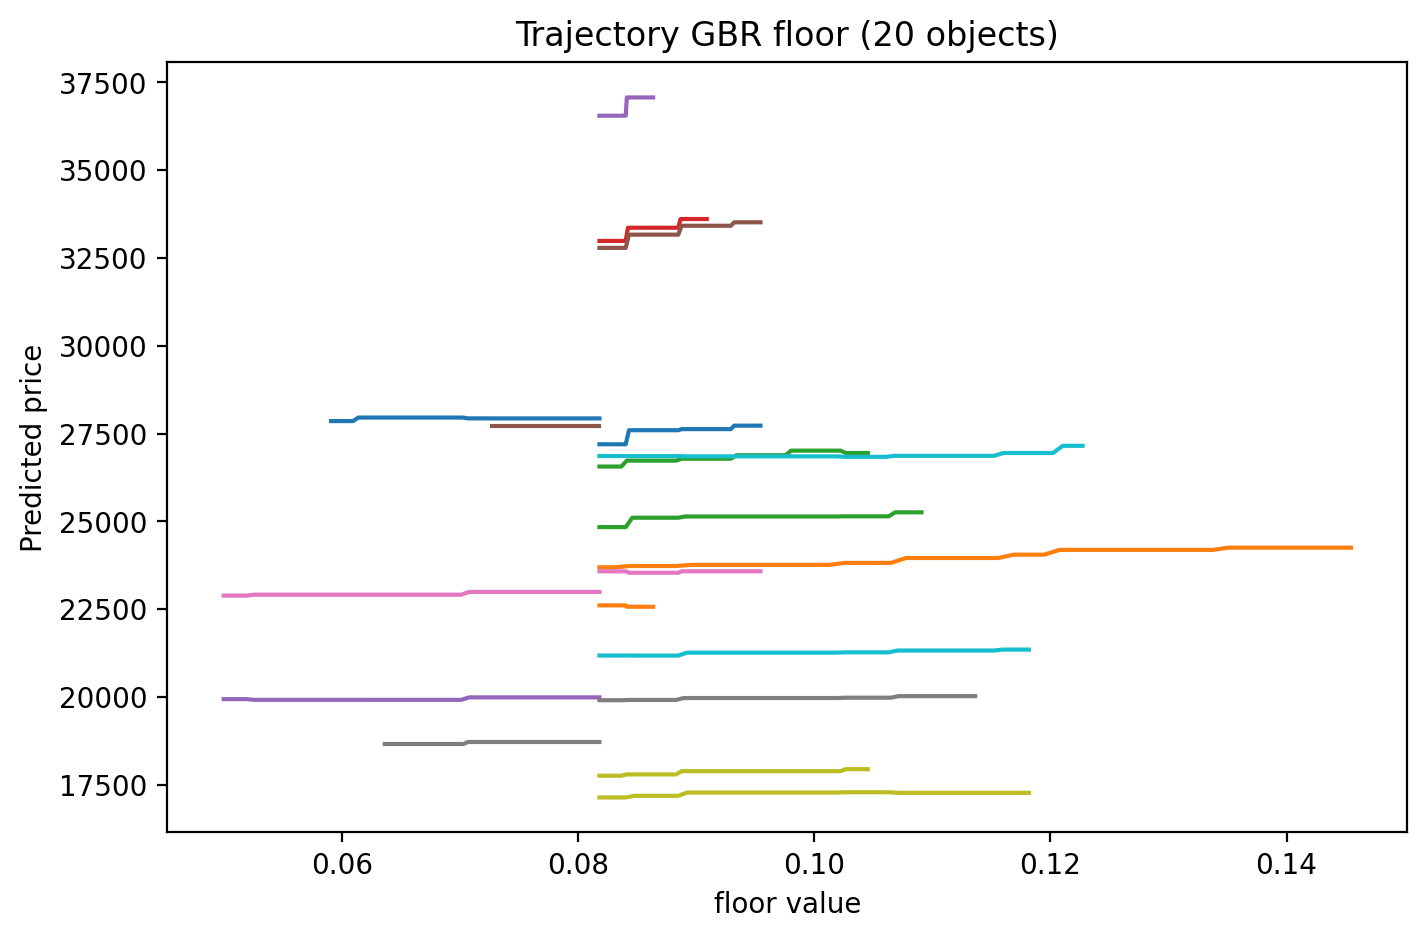

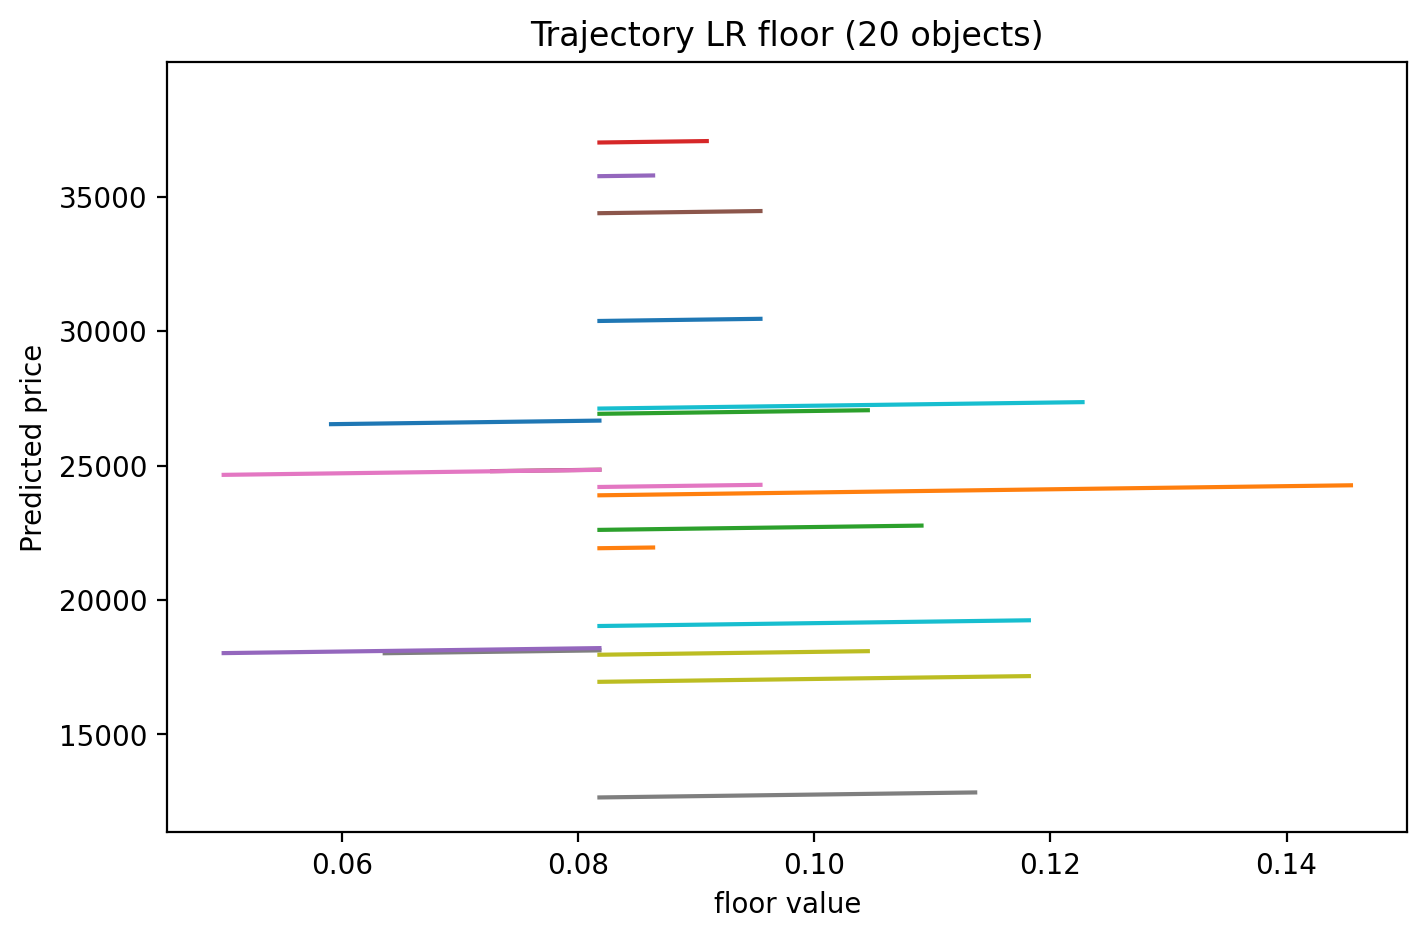

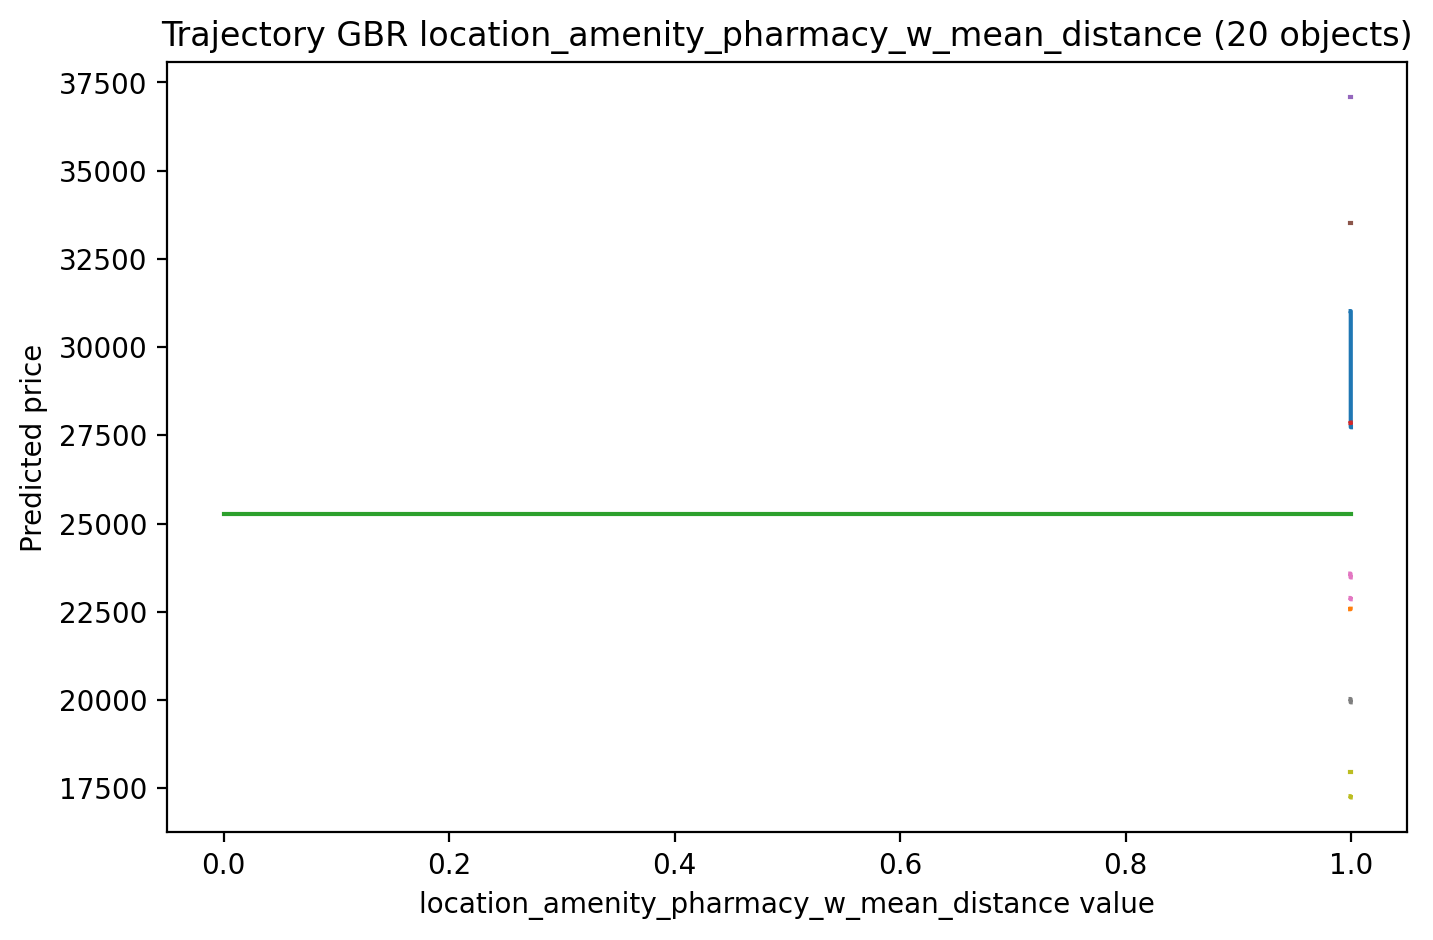

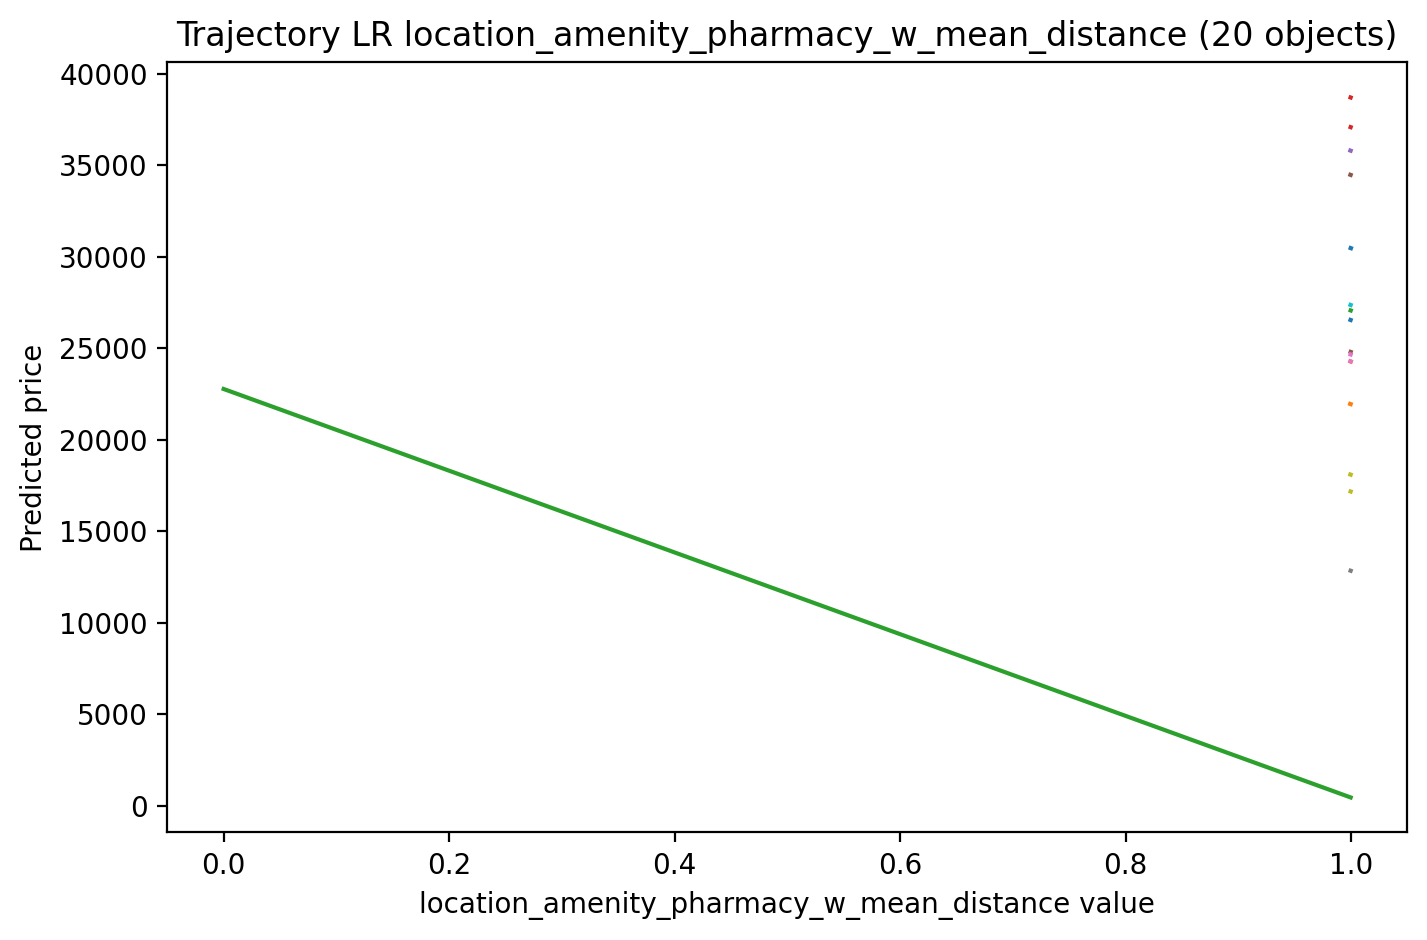

In [18]:
features = ["floor", "location_amenity_pharmacy_w_mean_distance"]
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, 20, replace=False)
n_steps = 50
medians = X_train.median()

for f in features:
    plt.figure(figsize=(8,5))
    for idx in sample_idx:
        traj_values = np.linspace(X_test.loc[idx, f], medians[f], n_steps)
        preds = []
        for val in traj_values:
            x_temp = X_test.loc[idx].copy()
            x_temp[f] = val
            preds.append(gbr.predict([x_temp.values])[0])
        plt.plot(traj_values, preds)
    plt.xlabel(f"{f} value")
    plt.ylabel("Predicted price")
    plt.title(f"Trajectory GBR {f} (20 objects)")
    plt.show()

    plt.figure(figsize=(8,5))
    for idx in sample_idx:
        traj_values = np.linspace(X_test.loc[idx, f], medians[f], n_steps)
        preds = []
        for val in traj_values:
            x_temp = X_test.loc[idx].copy()
            x_temp[f] = val
            preds.append(lr.predict([x_temp.values])[0])
        plt.plot(traj_values, preds)
    plt.xlabel(f"{f} value")
    plt.ylabel("Predicted price")
    plt.title(f"Trajectory LR {f} (20 objects)")
    plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.


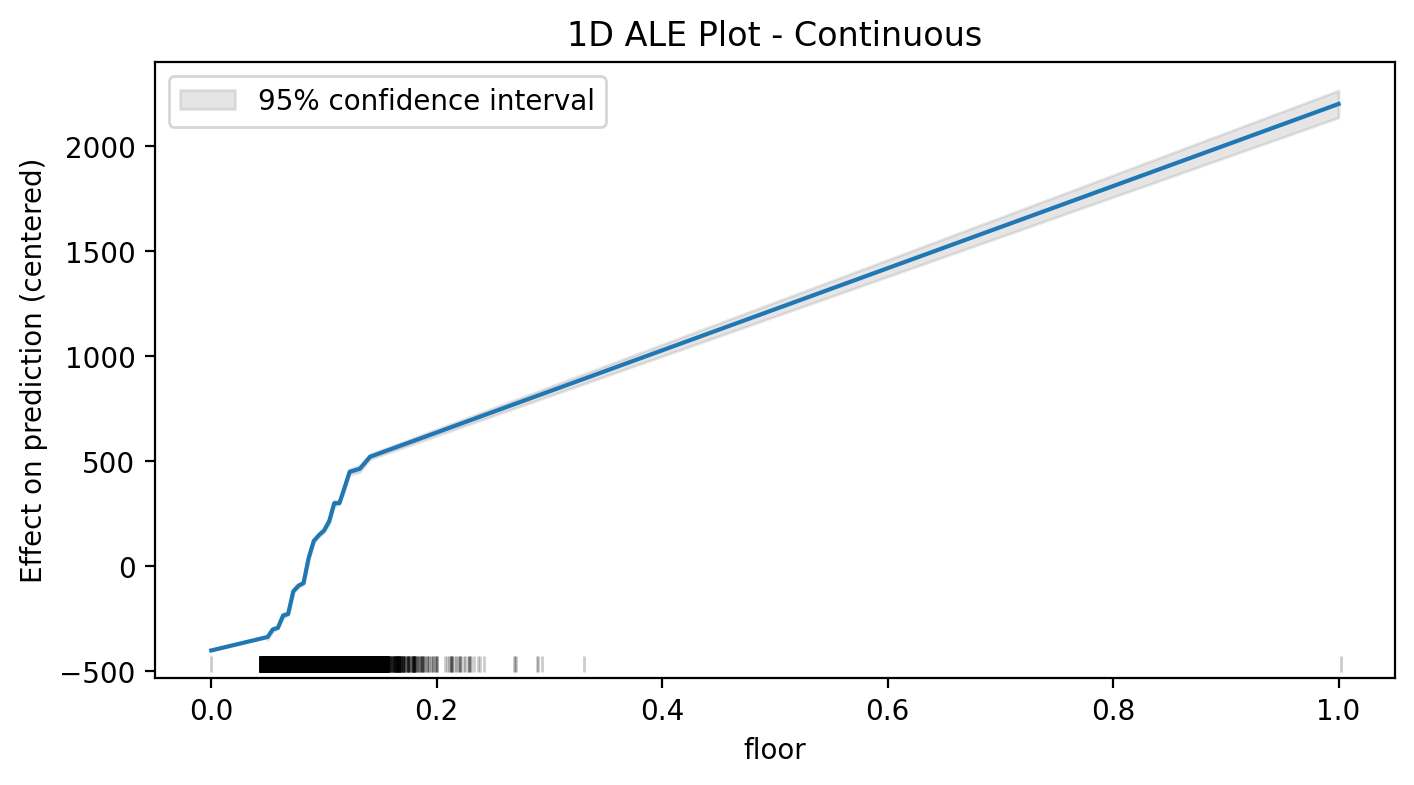

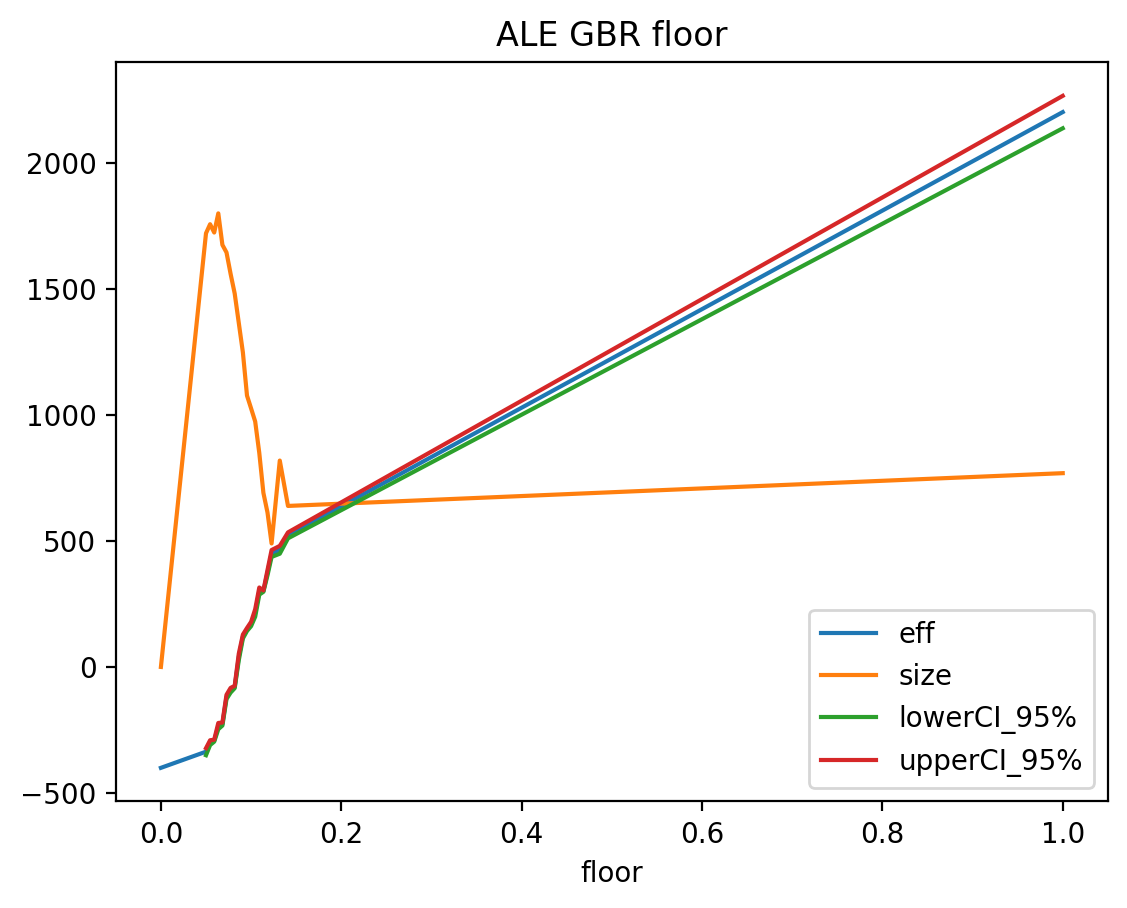

PyALE._ALE_generic:INFO: Continuous feature detected.


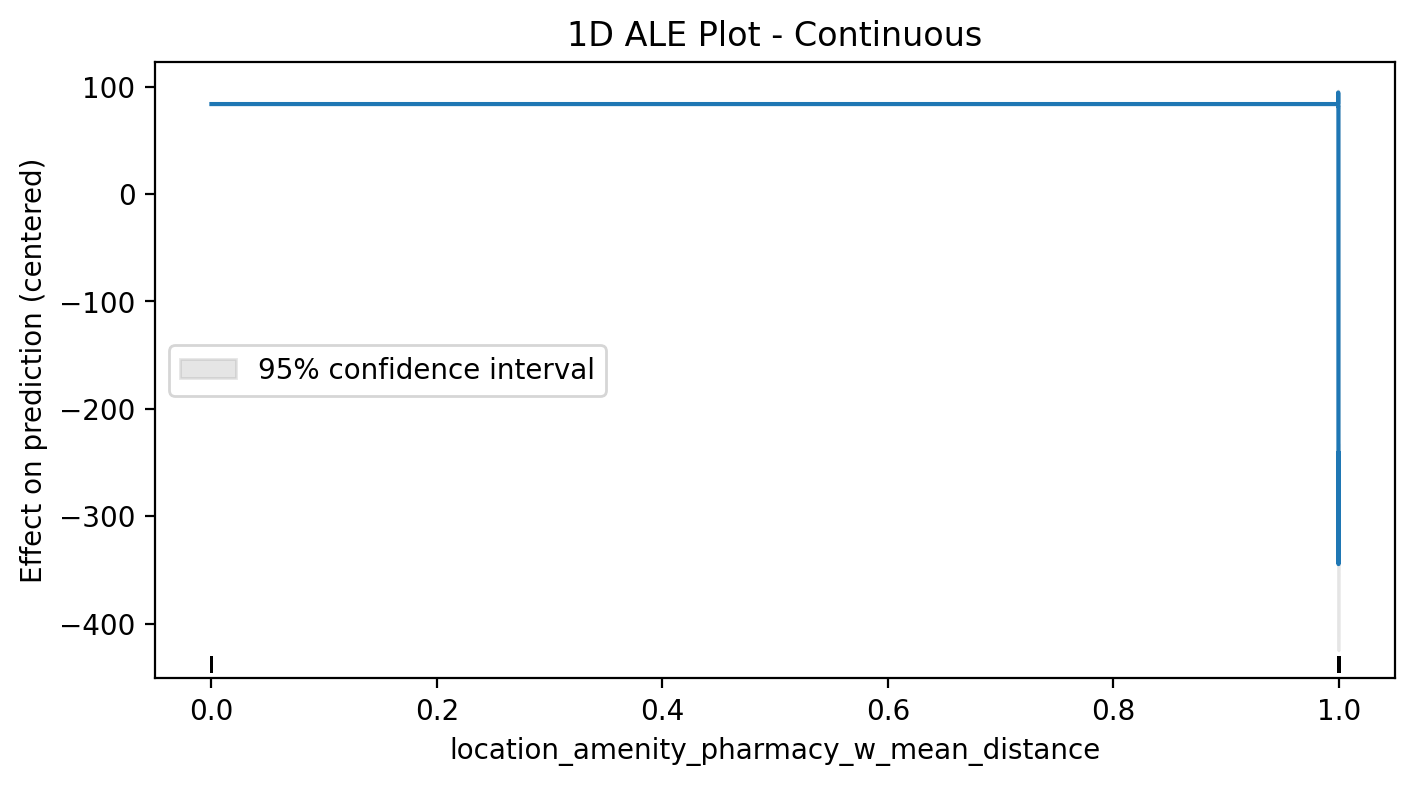

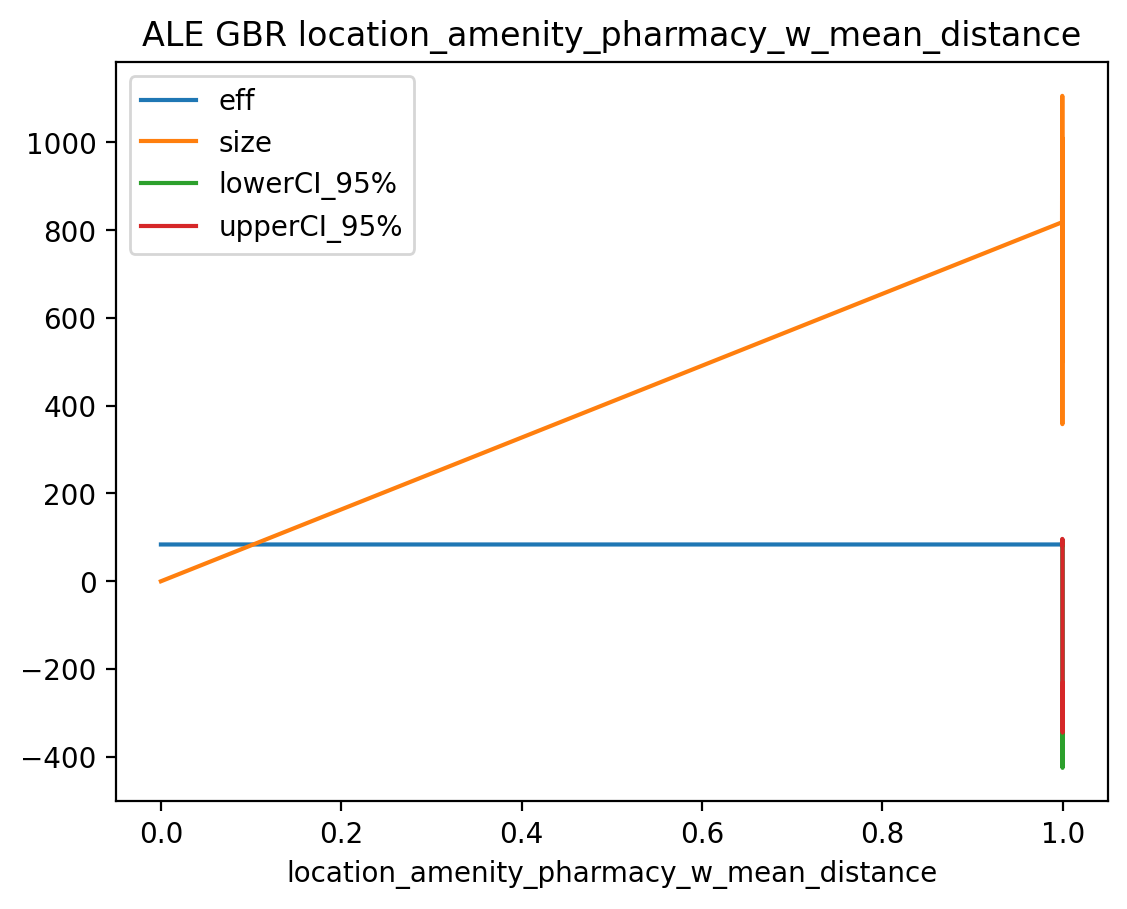

PyALE._ALE_generic:INFO: Continuous feature detected.


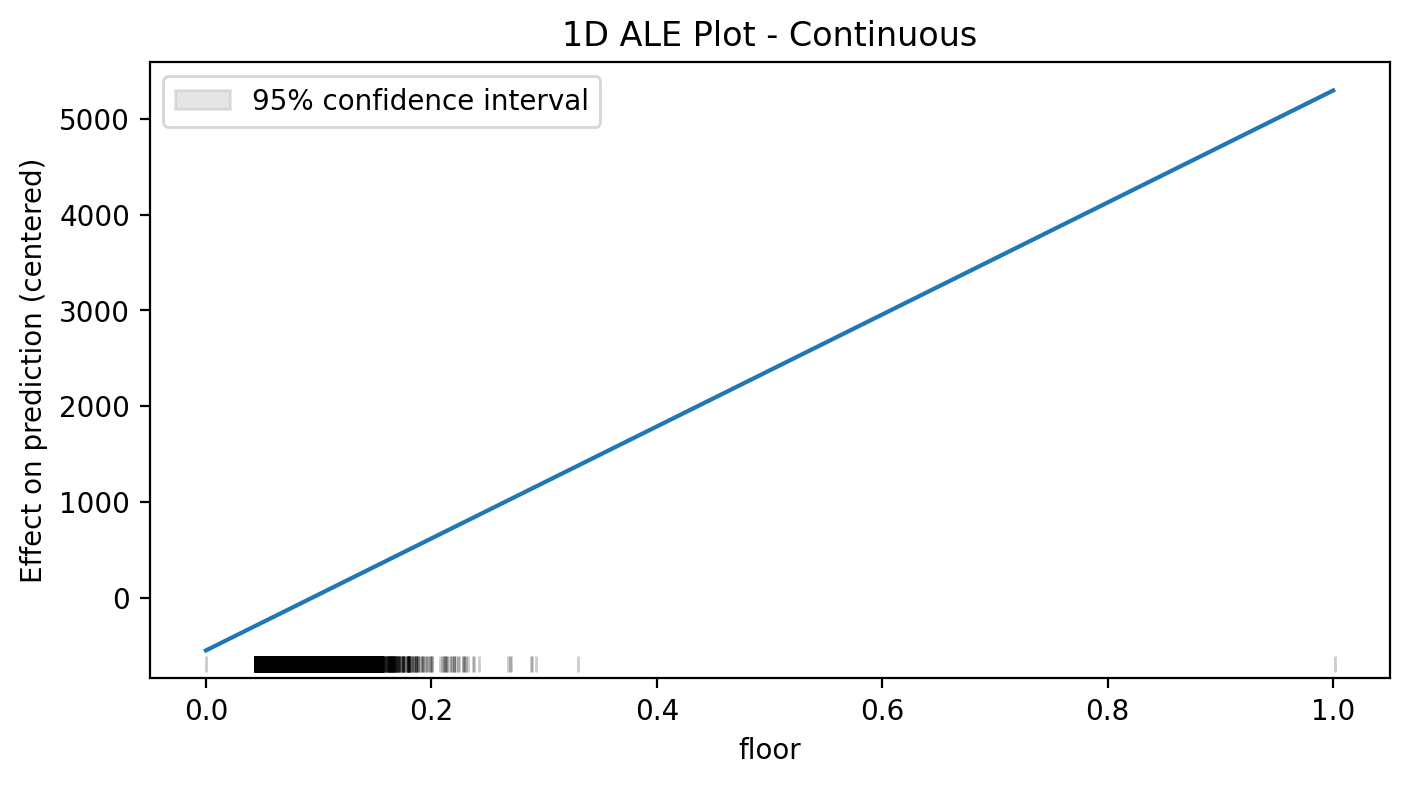

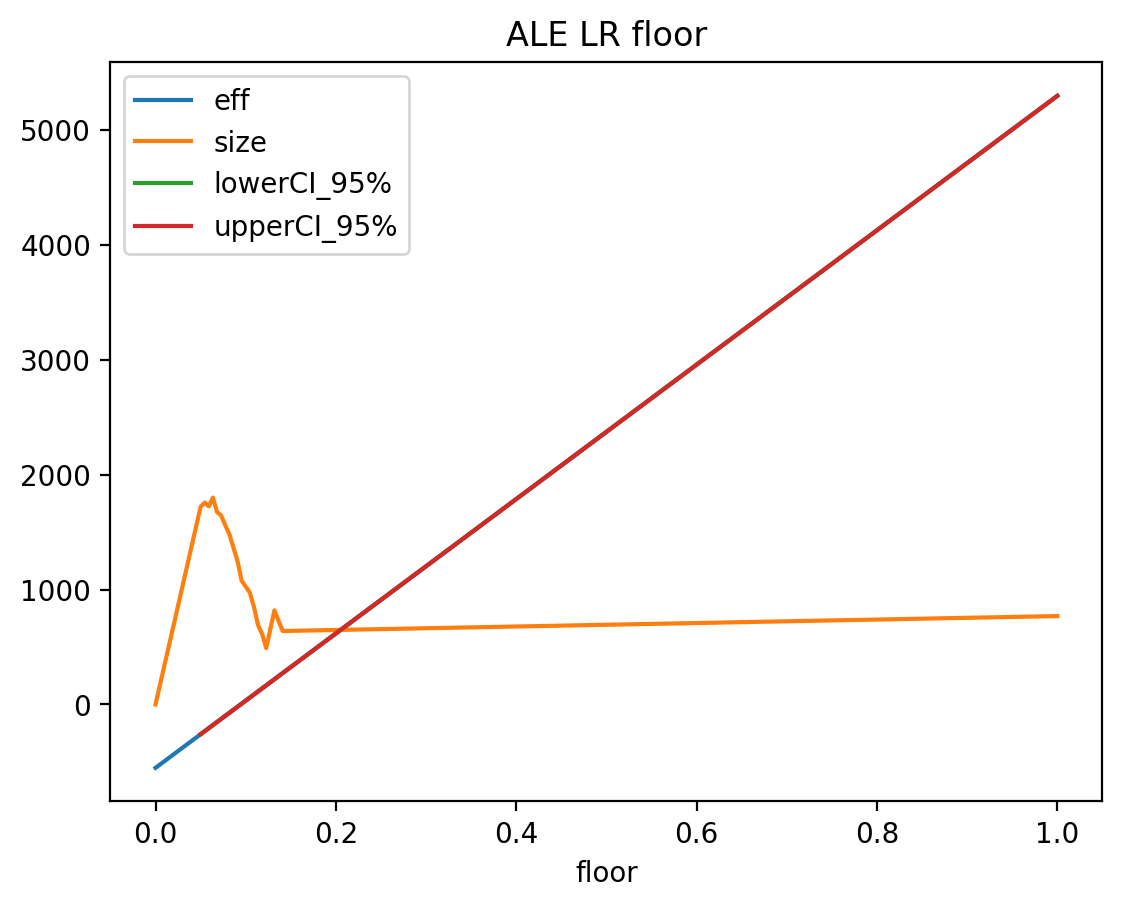

PyALE._ALE_generic:INFO: Continuous feature detected.


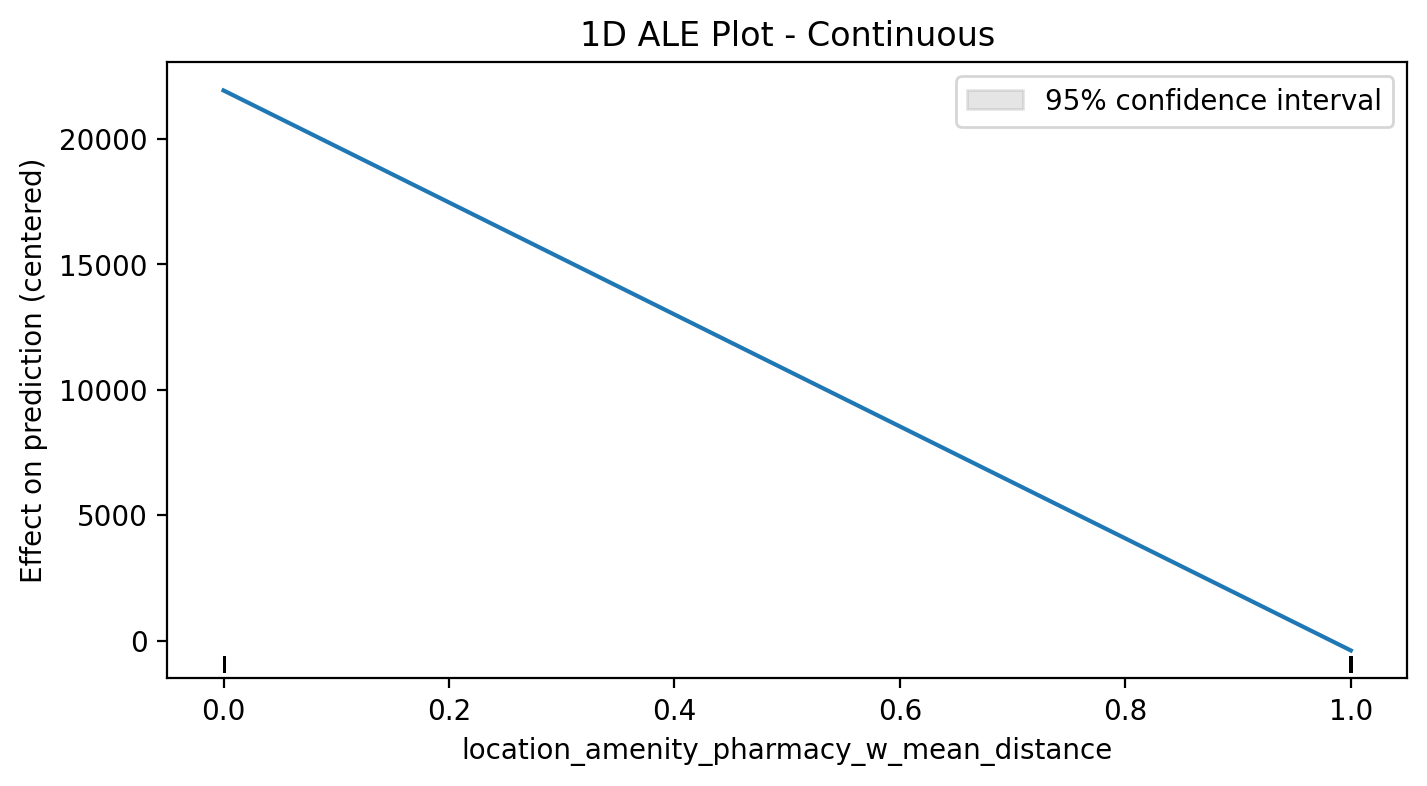

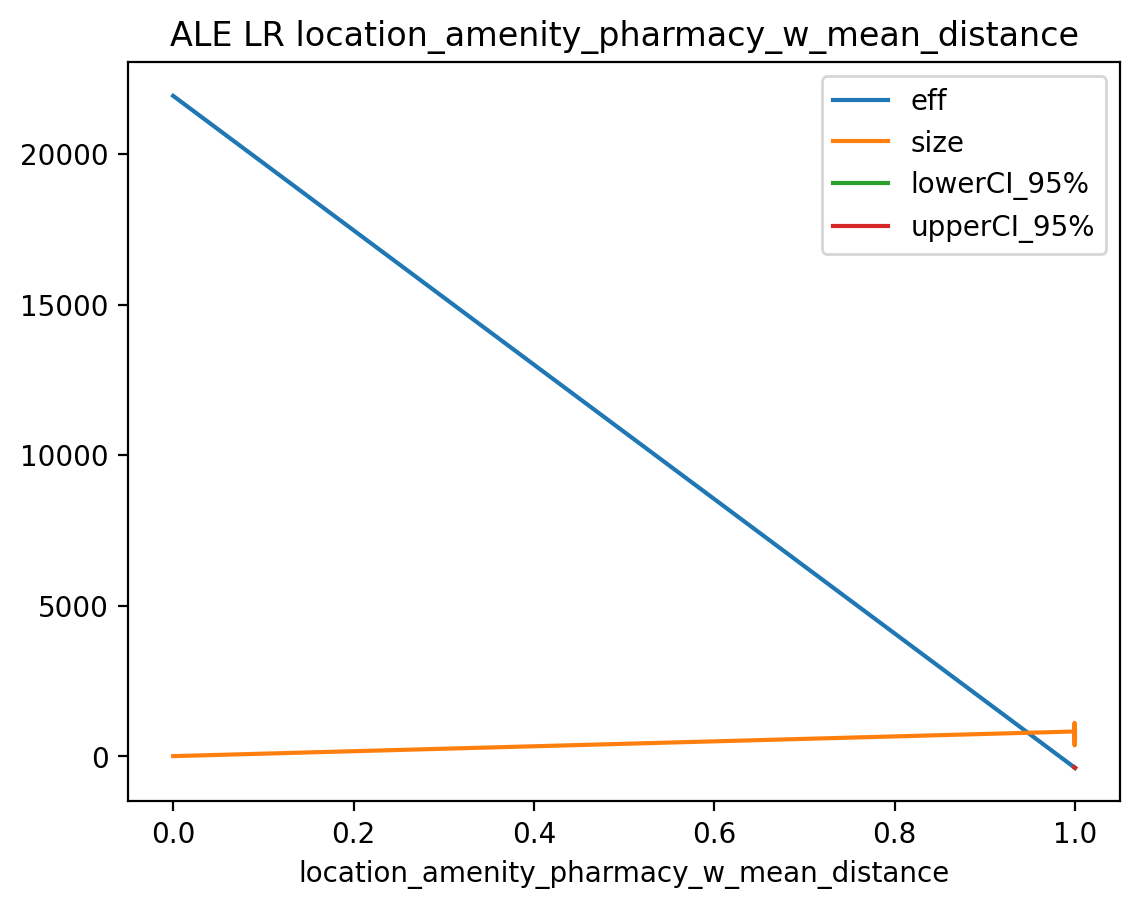

In [19]:
from PyALE import ale

features = ["floor", "location_amenity_pharmacy_w_mean_distance"]

for model, name in [(gbr, "GBR"), (lr, "LR")]:
    for f in features:
        ale_eff = ale(
            X=X_train,
            model=model,
            feature=[f],
            grid_size=30,
            include_CI=True,
            C=0.95
        )
        ale_eff.plot()
        plt.title(f"ALE {name} {f}")
        plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [20]:
from sklearn.inspection import permutation_importance

perm_nums = [5, 10, 30]
models = [(gbr, "GBR"), (lr, "LR")]

for model, name in models:
    print(f"Permutation Importance: {name}")
    for n in perm_nums:
        perm = permutation_importance(model, X_test, y_test, n_repeats=n, random_state=42, scoring='neg_mean_squared_error')
        imp_mean = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
        imp_std = pd.Series(perm.importances_std, index=X_test.columns).sort_values(ascending=False)
        print(f"\nNumber of permutations: {n}")
        display(pd.DataFrame({"mean": imp_mean.head(10), "std": imp_std.head(10)}))

Permutation Importance: GBR

Number of permutations: 5


,mean,std
class_cat,1.128325e+08,3.777447e+06
corpus_cat,NaN,5.555848e+04
district_cat,3.083978e+06,1.806957e+05
hc_name_cat,6.881367e+05,NaN
location_amenity_leisure_w_mean_distance,NaN,6.237432e+04
location_amenity_pharmacy_w_mean_distance,8.485918e+05,5.603930e+04
location_logs_count_mean,1.303333e+07,1.185211e+06
location_public_transport_stop_position_cnt,2.682387e+06,NaN
location_railway_w_mean_distance,3.294603e+06,7.262301e+05
location_school_w_mean_distance,NaN,7.257922e+04



Number of permutations: 10


,mean,std
class_cat,1.134185e+08,3.075140e+06
district_cat,2.936203e+06,2.671692e+05
hc_name_cat,6.947560e+05,NaN
location_amenity_leisure_w_mean_distance,NaN,5.887180e+04
location_amenity_pharmacy_w_mean_distance,8.429124e+05,5.852123e+04
location_logs_count_mean,1.221823e+07,1.343430e+06
location_public_transport_stop_position_cnt,2.670037e+06,6.696598e+04
location_railway_w_mean_distance,3.312669e+06,7.564677e+05
location_school_w_mean_distance,NaN,6.170730e+04
location_shop_product_w_mean_distance,NaN,1.323523e+05



Number of permutations: 30


...

,mean,std
class_cat,3.168643e+07,5.878005e+05
location_amenity_leisure_w_mean_distance,NaN,3.661491e+05
location_amenity_pharmacy_w_mean_distance,1.960376e+07,NaN
location_buildings_cnt,NaN,5.885705e+05
location_highway_crossing_w_mean_distance,1.364709e+13,1.323967e+11
location_pop_shop_w_mean_distance,2.742976e+07,NaN
location_public_transport_platform_w_mean_distance,1.716934e+13,1.671075e+11
location_shop_alco_cnt,NaN,3.836389e+05
location_shop_other_w_mean_distance,6.575060e+09,1.007850e+08
location_shop_product_w_mean_distance,2.040886e+11,1.961786e+09



Number of permutations: 10


,mean,std
class_cat,3.201276e+07,7.307286e+05
location_amenity_pharmacy_w_mean_distance,1.943194e+07,NaN
location_buildings_cnt,NaN,4.900062e+05
location_highway_crossing_w_mean_distance,1.364737e+13,1.796371e+11
location_pop_shop_cnt,NaN,4.520576e+05
location_pop_shop_w_mean_distance,2.735108e+07,NaN
location_public_transport_platform_w_mean_distance,1.716918e+13,2.259847e+11
location_railway_station_cnt,NaN,4.667551e+05
location_shop_other_w_mean_distance,6.608601e+09,9.556262e+07
location_shop_product_w_mean_distance,2.041041e+11,2.683736e+09



Number of permutations: 30


,mean,std
class_cat,3.180318e+07,6.875512e+05
location_amenity_pharmacy_w_mean_distance,1.962736e+07,4.798094e+05
location_buildings_cnt,NaN,4.356193e+05
location_highway_crossing_w_mean_distance,1.370148e+13,1.654815e+11
location_pop_shop_cnt,NaN,4.170431e+05
location_pop_shop_w_mean_distance,2.725724e+07,5.206471e+05
location_public_transport_platform_w_mean_distance,1.723714e+13,2.081374e+11
location_shop_other_w_mean_distance,6.639870e+09,8.212675e+07
location_shop_product_w_mean_distance,2.049171e+11,2.476569e+09
location_std_levels_mean,6.549628e+09,8.341763e+07


## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 
